In [36]:
import pandas as pd
import numpy as np
import io

import matplotlib.pyplot as plt
import seaborn as sns

sns.set()

In [23]:
# =========================================================
# STEP 1: LOAD & PREPARE THE GRID DATA
# =========================================================
print("Loading Taipower grid logs...")
df_taipower = pd.read_csv('data/taipower_data.csv')
df_taipower['Time_Occurred'] = pd.to_datetime(df_taipower['Time_Occurred'], errors='coerce')

weather_keywords = [
    '饋線事故停電', '饋線全停', '分歧開關跳脫', '欠相', '斷線', 
    '過流電驛動作', '差動電驛動作', '51動作', '51N動作', '斷路器跳脫', '越級跳脫'
]
pattern = '|'.join(weather_keywords)
df_grid_faults = df_taipower[df_taipower['Incident_Description'].str.contains(pattern, na=False)].copy()

Loading Taipower grid logs...


In [24]:
df_grid_faults

,Incident_ID,Time_Occurred,Incident_Description,Households_Affected,Time_Restored
0,1,2024-12-25 23:27:00,榮成變電所第59條饋線全停逾時一小時以上事故,1,2024-12-26 02:07:00
4,5,2024-12-10 11:30:00,西螺服務區南下休息站欠相停電事故,10,2024-12-10 16:00:00
14,15,2024-11-02 10:22:00,中部科學園區編號H467饋線事故停電,112,2024-11-02 10:22:00
27,28,2024-10-01 19:30:00,中部科學園區編號H875饋線事故停電(聯亞科技),1,2024-10-01 19:40:00
28,29,2024-09-28 18:15:00,興變電所9I28饋線相間過流電驛動作造成饋線斷路器跳脫，事故停電,"3,230",2024-09-28 18:42:00
35,36,2024-09-19 01:01:00,中正變電所第51號饋線事故停電,"3,093",2024-09-19 02:20:00
37,38,2024-09-16 17:55:00,成都變電所第62號饋線事故停電,"1,915",2024-09-16 18:39:00
44,45,2024-09-01 05:12:00,新豐配電變電所第59饋線事故停電,1,2024-09-01 05:16:00
51,52,2024-07-31 02:40:00,內惟配電變電所第74饋線斷路器跳脫事故停電,253,2024-07-31 03:29:00
55,56,2024-07-16 14:04:00,成都變電所第62饋線事故停電,"2,350",2024-07-16 14:09:00


In [26]:
# =========================================================
# STEP 2: LOAD STORM DATA & GEOMAP
# =========================================================
print("Loading JMA storm tracks...")
df_storm = pd.read_csv('data/typhoon_data_final.csv')

# Ensure we use Taiwan Local Time
df_storm['Timestamp'] = pd.to_datetime(df_storm['Timestamp'], errors='coerce') + pd.Timedelta(hours=8)
df_storm_2024 = df_storm[df_storm['Timestamp'].dt.year >= 2024].copy()

geomap_csv = """name,latitude,longitude
榮成變電所,25.05482,121.13183
西螺服務區,23.7987,120.4665
中部科學園區,24.2173,120.6997
興變電所,23.5,120.8
中正變電所,25.0329,121.5654
成都變電所,24.9936,121.3010
新豐配電變電所,24.9053,120.9839
內惟配電變電所,22.6663,120.2862
永華二次變電所,22.9908,120.2133
關西二次變電所,24.7920,121.1760
源海二次變電所,25.0330,121.5654
四湖配電變電所,23.6367,120.2250
新高港超高壓變電所,22.570017,120.407833
九曲配電變電所,22.9900,120.2000
崙背變電所,23.7580,120.3530
常德變電所,25.0600,121.5200
嶺口二次變電所,22.7580,120.3600
龍明配電變電所,24.9930,121.2960
新工配電變電所,24.8138,120.9675"""

df_geo = pd.read_csv(io.StringIO(geomap_csv))

Loading JMA storm tracks...


In [27]:
df_geo

,name,latitude,longitude
0,榮成變電所,25.054820,121.131830
1,西螺服務區,23.798700,120.466500
2,中部科學園區,24.217300,120.699700
3,興變電所,23.500000,120.800000
4,中正變電所,25.032900,121.565400
5,成都變電所,24.993600,121.301000
6,新豐配電變電所,24.905300,120.983900
7,內惟配電變電所,22.666300,120.286200
8,永華二次變電所,22.990800,120.213300
9,關西二次變電所,24.792000,121.176000


In [28]:
# =========================================================
# STEP 3: CARTESIAN ALIGNMENT & PHYSICS ENGINE
# =========================================================
def haversine(lat1, lon1, lat2, lon2):
    R = 6371.0 
    dLat, dLon = np.radians(lat2 - lat1), np.radians(lon2 - lon1)
    a = np.sin(dLat/2)**2 + np.cos(np.radians(lat1)) * np.cos(np.radians(lat2)) * np.sin(dLon/2)**2
    return R * (2 * np.arctan2(np.sqrt(a), np.sqrt(1-a)))

df_storm_2024['key'], df_geo['key'] = 1, 1
df_cross = pd.merge(df_storm_2024, df_geo, on='key').drop('key', axis=1)

df_cross['Distance_to_Node_km'] = haversine(
    df_cross['latitude'], df_cross['longitude'], 
    df_cross['Latitude'], df_cross['Longitude'] 
)

# Wide radius (1500km) to capture early storm staging and massive outer bands
df_danger = df_cross[df_cross['Distance_to_Node_km'] <= 1500.0].copy()

TIME_WINDOW = pd.Timedelta(hours=24)

def verify_node_failure(node_name, storm_time, grid_df, window):
    mask = (
        (grid_df['Time_Occurred'] >= storm_time - window) & 
        (grid_df['Time_Occurred'] <= storm_time + window) & 
        (grid_df['Incident_Description'].str.contains(node_name, na=False))
    )
    return 1 if mask.any() else 0

print(f"\nEvaluating {len(df_danger)} localized danger zone events...")

df_danger['Target_Failure'] = df_danger.apply(
    lambda row: verify_node_failure(row['name'], row['Timestamp'], df_grid_faults, TIME_WINDOW), 
    axis=1
)


Evaluating 15555 localized danger zone events...


In [29]:
# =========================================================
# STEP 4: FINALIZE QUANTUM DATASET (FEATURE UPGRADE)
# =========================================================
# Swapped 'Wind_Knots' for 'Grade' to prevent zero-value confusion
qkn_features = ['Timestamp', 'name', 'Storm_Name', 'Grade', 'Pressure', 'Distance_to_Node_km', 'Target_Failure']
df_qkn_final = df_danger[qkn_features].rename(columns={'name': 'Node_Name'})

print("\n=== PHASE 1 & 2 COMPLETE ===")
print("Balanced Target Class Distribution:")
print(df_qkn_final['Target_Failure'].value_counts())
print("\nSample Data Ready for QKN:")
print(df_qkn_final.head())


=== PHASE 1 & 2 COMPLETE ===
Balanced Target Class Distribution:
Target_Failure
0    15499
1       56
Name: count, dtype: int64

Sample Data Ready for QKN:
             Timestamp Node_Name Storm_Name  Grade  Pressure  \
77 2024-05-25 02:00:00     西螺服務區    EWINIAR      2    1004.0   
79 2024-05-25 02:00:00      興變電所    EWINIAR      2    1004.0   
83 2024-05-25 02:00:00   內惟配電變電所    EWINIAR      2    1004.0   
84 2024-05-25 02:00:00   永華二次變電所    EWINIAR      2    1004.0   
87 2024-05-25 02:00:00   四湖配電變電所    EWINIAR      2    1004.0   

    Distance_to_Node_km  Target_Failure  
77          1480.794552               0  
79          1437.763521               0  
83          1371.301527               0  
84          1407.368499               0  
87          1473.112499               0  


In [30]:
set(df_qkn_final['Target_Failure'])

{0, 1}

In [31]:
df_qkn_final

,Timestamp,Node_Name,Storm_Name,Grade,Pressure,Distance_to_Node_km,Target_Failure
77,2024-05-25 02:00:00,西螺服務區,EWINIAR,2,1004.0,1480.794552,0
79,2024-05-25 02:00:00,興變電所,EWINIAR,2,1004.0,1437.763521,0
83,2024-05-25 02:00:00,內惟配電變電所,EWINIAR,2,1004.0,1371.301527,0
84,2024-05-25 02:00:00,永華二次變電所,EWINIAR,2,1004.0,1407.368499,0
87,2024-05-25 02:00:00,四湖配電變電所,EWINIAR,2,1004.0,1473.112499,0
...,...,...,...,...,...,...,...
34074,2025-12-03 08:00:00,內惟配電變電所,KOTO,2,1010.0,1444.230756,0
34075,2025-12-03 08:00:00,永華二次變電所,KOTO,2,1010.0,1464.190790,0
34079,2025-12-03 08:00:00,新高港超高壓變電所,KOTO,2,1010.0,1445.906247,0
34080,2025-12-03 08:00:00,九曲配電變電所,KOTO,2,1010.0,1463.167230,0


In [32]:
df_qkn_final[df_qkn_final['Target_Failure'] == 1]

,Timestamp,Node_Name,Storm_Name,Grade,Pressure,Distance_to_Node_km,Target_Failure
6979,2024-09-01 14:00:00,新豐配電變電所,YAGI,3,1000.0,1381.852162,1
6998,2024-09-01 20:00:00,新豐配電變電所,YAGI,3,1000.0,1264.191953,1
7017,2024-09-02 02:00:00,新豐配電變電所,YAGI,3,996.0,1179.958478,1
8688,2024-09-15 20:00:00,成都變電所,BEBINCA,5,965.0,692.750820,1
8707,2024-09-16 02:00:00,成都變電所,BEBINCA,5,970.0,653.633854,1
8726,2024-09-16 08:00:00,成都變電所,BEBINCA,5,980.0,669.672716,1
8745,2024-09-16 14:00:00,成都變電所,BEBINCA,4,985.0,716.662735,1
8764,2024-09-16 20:00:00,成都變電所,BEBINCA,4,992.0,770.945983,1
8783,2024-09-17 02:00:00,成都變電所,BEBINCA,3,1000.0,832.869852,1
8802,2024-09-17 08:00:00,成都變電所,BEBINCA,2,1004.0,915.315323,1


In [34]:
# --- EDA ---
# 1. Basics
print("=== BASIC INFO ===")
print(df_qkn_final.info())
print("\n=== SUMMARY STATISTICS ===")
df_qkn_final.describe()

=== BASIC INFO ===
<class 'pandas.core.frame.DataFrame'>
Index: 15555 entries, 77 to 34083
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Timestamp            15555 non-null  datetime64[ns]
 1   Node_Name            15555 non-null  object        
 2   Storm_Name           15555 non-null  object        
 3   Grade                15555 non-null  int64         
 4   Pressure             15555 non-null  float64       
 5   Distance_to_Node_km  15555 non-null  float64       
 6   Target_Failure       15555 non-null  int64         
dtypes: datetime64[ns](1), float64(2), int64(2), object(2)
memory usage: 972.2+ KB
None

=== SUMMARY STATISTICS ===


,Timestamp,Grade,Pressure,Distance_to_Node_km,Target_Failure
count,15555,15555.000000,15555.000000,15555.000000,15555.000000
mean,2025-03-04 07:03:24.358727168,3.451623,985.421344,927.182896,0.003600
min,2024-05-25 02:00:00,2.000000,905.000000,3.429577,0.000000
25%,2024-09-17 20:00:00,2.000000,980.000000,678.224377,0.000000
50%,2024-11-18 20:00:00,3.000000,992.000000,946.248903,0.000000
75%,2025-08-22 14:00:00,5.000000,1000.000000,1223.491750,0.000000
max,2025-12-03 08:00:00,6.000000,1012.000000,1499.872775,1.000000
std,NaN,1.200819,21.180753,353.021709,0.059895


C:\Users\Diem\AppData\Local\Temp\ipykernel_27416\117644680.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_qkn_final, x='Target_Failure', ax=axes[0,0], palette='viridis')
C:\Users\Diem\AppData\Local\Temp\ipykernel_27416\117644680.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_qkn_final, x='Target_Failure', y='Distance_to_Node_km', ax=axes[0,1], palette='viridis')
C:\Users\Diem\AppData\Local\Temp\ipykernel_27416\117644680.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_qkn_final, x='Target_Failure', y=

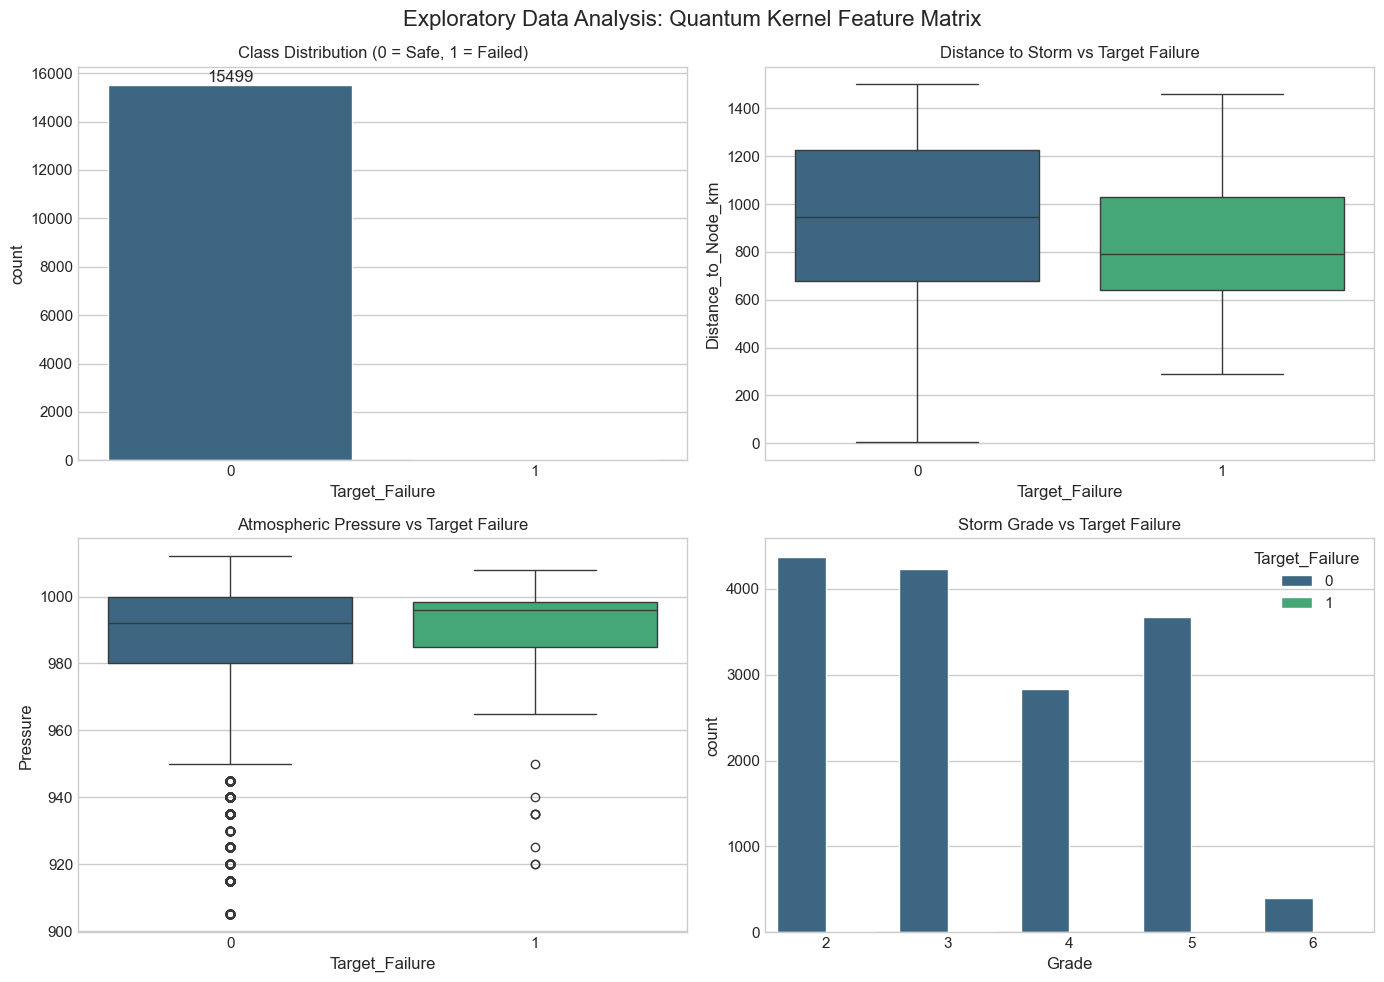


=== MEAN STATS BY CLASS ===
                Distance_to_Node_km    Pressure     Grade
Target_Failure                                           
0                        927.563901  985.418930  3.452094
1                        821.732730  986.089286  3.321429


In [37]:
# 2. Visualizations
plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Exploratory Data Analysis: Quantum Kernel Feature Matrix', fontsize=16)

# A. Class Distribution
sns.countplot(data=df_qkn_final, x='Target_Failure', ax=axes[0,0], palette='viridis')
axes[0,0].set_title('Class Distribution (0 = Safe, 1 = Failed)')
axes[0,0].bar_label(axes[0,0].containers[0])

# B. Distance vs Failure
sns.boxplot(data=df_qkn_final, x='Target_Failure', y='Distance_to_Node_km', ax=axes[0,1], palette='viridis')
axes[0,1].set_title('Distance to Storm vs Target Failure')

# C. Pressure vs Failure
sns.boxplot(data=df_qkn_final, x='Target_Failure', y='Pressure', ax=axes[1,0], palette='viridis')
axes[1,0].set_title('Atmospheric Pressure vs Target Failure')

# D. Grade vs Failure
sns.countplot(data=df_qkn_final, x='Grade', hue='Target_Failure', ax=axes[1,1], palette='viridis')
axes[1,1].set_title('Storm Grade vs Target Failure')

plt.tight_layout()
plt.show()

# Quick stat comparison
print("\n=== MEAN STATS BY CLASS ===")
print(df_qkn_final.groupby('Target_Failure')[['Distance_to_Node_km', 'Pressure', 'Grade']].mean())

<Axes: >

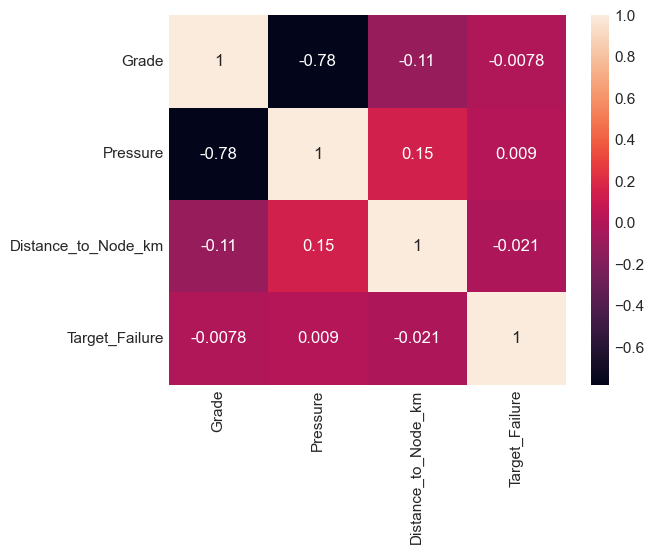

In [40]:
sns.heatmap(df_qkn_final[['Grade', 'Pressure', 'Distance_to_Node_km', 'Target_Failure']].corr(method='spearman'),
           annot=True)

In [42]:
print(df_qkn_final[['Grade', 'Pressure', 'Distance_to_Node_km', 'Target_Failure']].corr(method='spearman'))

                        Grade  Pressure  Distance_to_Node_km  Target_Failure
Grade                1.000000 -0.781570            -0.111638       -0.007764
Pressure            -0.781570  1.000000             0.148809        0.009031
Distance_to_Node_km -0.111638  0.148809             1.000000       -0.020621
Target_Failure      -0.007764  0.009031            -0.020621        1.000000


In [44]:
df_qkn_final.to_csv('data/qkn_data.csv', index=False)

In [45]:
df_qkn_final['Target_Failure'].value_counts()

Target_Failure
0    15499
1       56
Name: count, dtype: int64